<a href="https://colab.research.google.com/github/husthorng/Backpropagation_NN/blob/main/ANN_new_1141.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#https://drive.google.com/file/d/1DENGbC66jn0VJPkzSb0pjfWuRyvlz08j/view?usp=drive_link
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from google.colab import auth
import gspread
from google.auth import default
auth.authenticate_user()

import numpy as np

def logistic(x):
    return 1 / (1 + np.exp(-x))

maxcycles = 90000
SSE_Goal = 0.1
lr = 0.001

SSE_log = []


creds, _ = default()
gc = gspread.authorize(creds)
#在雲端硬碟 建立速算表 cloud_data 工作表 data
#https://docs.google.com/spreadsheets/d/15kZWq3YmtF5yx40BRuz6TMGx0D22_r9QO-ea84BaRKQ/edit?gid=0#gid=0
sh = gc.open("cloud_data")
worksheet = sh.worksheet("data")

#data = worksheet.get_all_values()
data = worksheet.get_all_values()[1:]

data_np = np.array(data, dtype=float)

min_v = np.min(data_np, axis=0)
max_v = np.max(data_np, axis=0)

data_norm = (data_np - min_v) / (max_v - min_v)
x=data_norm[:,0:4]
t=data_norm[:,4:6]

X = np.hstack((x, np.ones((x.shape[0], 1))))
patterns,inputs  = x.shape
_, outputs = t.shape

hidden = 6

np.random.seed()

W1 = 0.5 * np.random.randn(inputs+1, hidden)
W2 = 0.5 * np.random.randn(hidden+1, outputs)

#下載W1W2.npz
#https://github.com/husthorng/Backpropagation_NN/blob/main/W1W2.npz
w=np.load("/content/drive/MyDrive/W1W2.npz")
W1 = w['W1']
W2 = w['W2']



fileID = open("/content/drive/MyDrive/exp.txt","w")

# ===============================
# Training Loop
# ===============================

for k in range(maxcycles):

  # forward
  h = logistic(X @ W1)
  H = np.hstack((h, np.ones((h.shape[0],1))))
  output = logistic(H @ W2)

  e = t - output
  SSE = np.sum(e**2)
  SSE_log.append(SSE)


  if k % 1000 == 0:
      eti = np.sum(e[0,:]**2)
      ete = np.sum(e[1,:]**2)
      print(f"Epoch={k}, SSE={SSE:.8f}")
      fileID.write(f"{k} {SSE:.8f} {eti:.8f} {ete:.8f}\n")

  if SSE < SSE_Goal:
      print("Goal reached")
      break

  # backprop
  delta2 = output * (1-output) * e
  W2 += 2 * lr * H.T @ delta2

  delta1 = h * (1-h) * (delta2 @ W2[:-1,:].T)
  W1 += 2 * lr * X.T @ delta1

fileID.close()
# Save model
np.savez("/content/drive/MyDrive/W1W2.npz", W1=W1, W2=W2, max_v=max_v, min_v=min_v)

print("Training Finished")
# ===============================
# Predict
# ===============================
h = logistic(X @ W1)
H = np.hstack((h, np.ones((h.shape[0],1))))
output = logistic(H @ W2)

# 反正規化
OV = output * (max_v - min_v)[4:6] + min_v[4:6]


In [ ]:
SSE_log

In [4]:
real = data_np[:,4:6]

out_all = np.hstack((real, OV))

worksheet_out = sh.worksheet("output")

header = [["Ti_real","Te_real","Ti_pred","Te_pred"]]

#worksheet_out.clear()
worksheet_out.update("A1", header + out_all.tolist())
#https://docs.google.com/spreadsheets/d/15kZWq3YmtF5yx40BRuz6TMGx0D22_r9QO-ea84BaRKQ/edit?gid=0#gid=0

/tmp/ipykernel_215/263937359.py:10: DeprecationWarning: The order of arguments in worksheet.update() has changed. Please pass values first and range_name secondor used named arguments (range_name=, values=)
  worksheet_out.update("A1", header + out_all.tolist())


{'spreadsheetId': '15kZWq3YmtF5yx40BRuz6TMGx0D22_r9QO-ea84BaRKQ',
 'updatedRange': 'output!A1:D371',
 'updatedRows': 371,
 'updatedColumns': 4,
 'updatedCells': 1484}

In [6]:
try:
    ws_log = sh.worksheet("train_log")
except:
    ws_log = sh.add_worksheet(title="train_log", rows="1000", cols="10")

log_data = [[i, v] for i,v in enumerate(SSE_log)]

ws_log.clear()
ws_log.update("A1",[["epoch","SSE"]] + log_data)

/tmp/ipykernel_215/68557470.py:9: DeprecationWarning: The order of arguments in worksheet.update() has changed. Please pass values first and range_name secondor used named arguments (range_name=, values=)
  ws_log.update("A1",[["epoch","SSE"]] + log_data)


{'spreadsheetId': '15kZWq3YmtF5yx40BRuz6TMGx0D22_r9QO-ea84BaRKQ',
 'updatedRange': 'train_log!A1:B90001',
 'updatedRows': 90001,
 'updatedColumns': 2,
 'updatedCells': 180002}

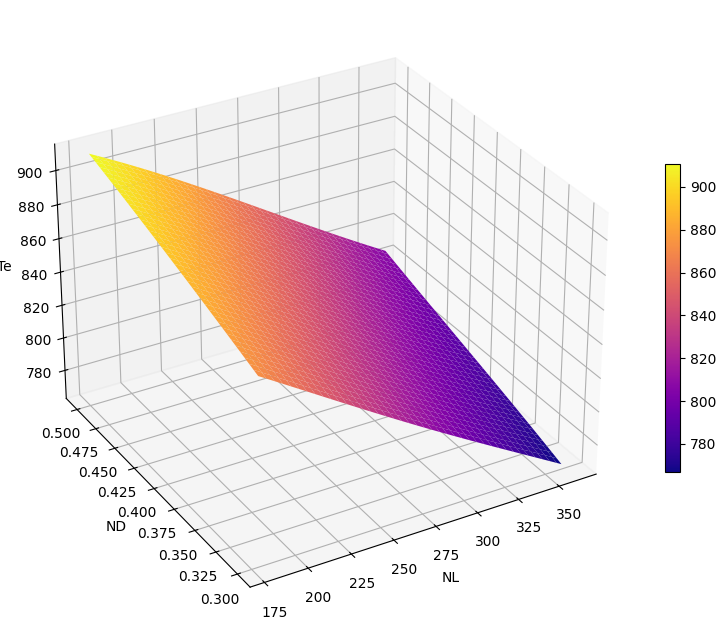

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 建立 X0 X1 grid
# -------------------------

x0 = np.linspace(min_v[0], max_v[0], 120)
x1 = np.linspace(min_v[1], max_v[1], 120)

X0, X1 = np.meshgrid(x0, x1)

# -------------------------
# 固定其他變數
# -------------------------

x2 = np.mean(data_np[:,2])
x3 = np.mean(data_np[:,3])

# -------------------------
# 組成 NN input
# -------------------------

grid = np.zeros((X0.size,4))

grid[:,0] = X0.ravel()
grid[:,1] = X1.ravel()
grid[:,2] = x2
grid[:,3] = x3

# 正規化
grid_norm = (grid - min_v[0:4]) / (max_v[0:4] - min_v[0:4])

# 加 bias
Xg = np.hstack((grid_norm, np.ones((grid_norm.shape[0],1))))

# -------------------------
# NN Forward
# -------------------------

h = logistic(Xg @ W1)
H = np.hstack((h, np.ones((h.shape[0],1))))

out = logistic(H @ W2)

# -------------------------
# 反正規化
# -------------------------

OV = out * (max_v - min_v)[4:6] + min_v[4:6]

# 取 Te
Z = OV[:,1].reshape(X0.shape)

# -------------------------
# 畫 3D surface
# -------------------------

fig = plt.figure(figsize=(10,8))


ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    X0,
    X1,
    Z,
    cmap='plasma',
    linewidth=0,
    antialiased=True
)


ax.set_xlabel("NL")
ax.set_ylabel("ND")
ax.set_zlabel("Te")

fig.colorbar(surf, shrink=0.5)

ax.view_init(elev=35, azim=-135)
ax.view_init(elev=30, azim=-120)
plt.show()

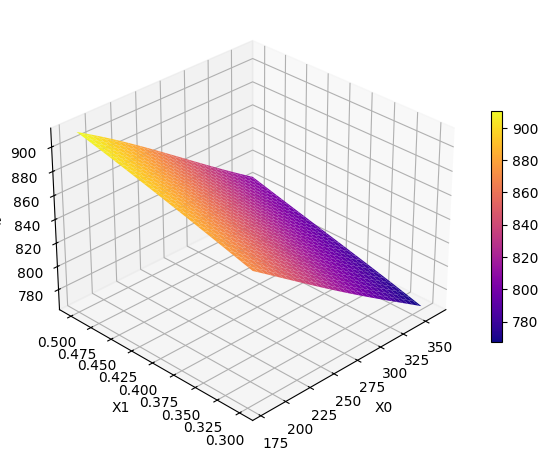

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# -------------------------
# 建立 X0 X1 grid
# -------------------------

x0 = np.linspace(min_v[0], max_v[0], 60)
x1 = np.linspace(min_v[1], max_v[1], 60)

X0, X1 = np.meshgrid(x0, x1)

# 固定其他變數
x2 = np.mean(data_np[:,2])
x3 = np.mean(data_np[:,3])

# -------------------------
# 組成 NN input
# -------------------------


grid = np.zeros((X0.size,4))

grid[:,0] = X0.ravel()
grid[:,1] = X1.ravel()
grid[:,2] = x2
grid[:,3] = x3

# 正規化
grid_norm = (grid - min_v[0:4]) / (max_v[0:4] - min_v[0:4])

# 加 bias
Xg = np.hstack((grid_norm, np.ones((grid_norm.shape[0],1))))

# -------------------------
# NN Forward
# -------------------------

h = logistic(Xg @ W1)
H = np.hstack((h, np.ones((h.shape[0],1))))
out = logistic(H @ W2)

# 反正規化
OV = out * (max_v - min_v)[4:6] + min_v[4:6]

# 取第6欄 (index=1)
Z = OV[:,1].reshape(X0.shape)

# -------------------------
# 畫 3D surface
# -------------------------

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')


surf = ax.plot_surface(
    X0,
    X1,
    Z,
    cmap='plasma',
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("X0")
ax.set_ylabel("X1")
ax.set_zlabel("Te")

fig.colorbar(surf, shrink=0.5)
ax.view_init(elev=30, azim=-135)



plt.show()

In [ ]:
X0.ravel().shape

(14400,)

In [ ]:
grid.shape


(14400, 4)

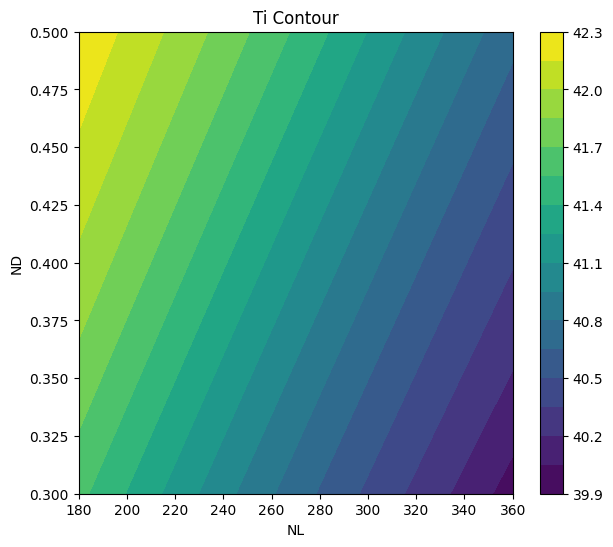

In [9]:
import matplotlib.pyplot as plt

# ===============================
# 建立 grid
# ===============================

x0 = np.linspace(min_v[0], max_v[0], 80)
x1 = np.linspace(min_v[1], max_v[1], 80)

X0, X1 = np.meshgrid(x0, x1)

# 固定其他兩個變數 (取平均值)
x2 = (max_v[2] + min_v[2]) / 2
x3 = (max_v[3] + min_v[3]) / 2

# ===============================
# 組合 NN 輸入
# ===============================

grid = np.column_stack([
    X0.ravel(),
    X1.ravel(),
    np.full(X0.size, x2),
    np.full(X0.size, x3)
])

# 正規化
grid_norm = (grid - min_v[0:4]) / (max_v[0:4] - min_v[0:4])

Xg = np.hstack((grid_norm, np.ones((grid_norm.shape[0],1))))

# ===============================
# NN 預測
# ===============================

h = logistic(Xg @ W1)
H = np.hstack((h, np.ones((h.shape[0],1))))
out = logistic(H @ W2)

# 反正規化
out_real = out * (max_v[4:6] - min_v[4:6]) + min_v[4:6]

Ti = out_real[:,0].reshape(X0.shape)
Te = out_real[:,1].reshape(X0.shape)

# ===============================
# 畫 Ti 等高線
# ===============================

plt.figure(figsize=(7,6))

cs = plt.contourf(X0, X1, Ti, 20)
plt.colorbar(cs)

plt.xlabel("NL")
plt.ylabel("ND")
plt.title("Ti Contour")

plt.show()

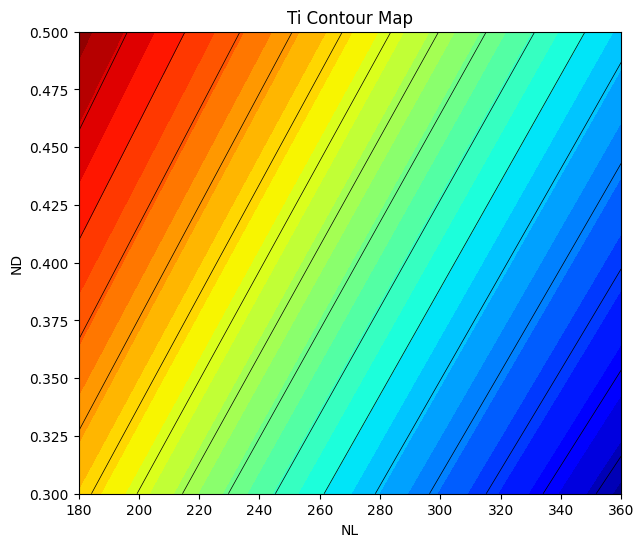

In [13]:
plt.figure(figsize=(7,6))

cs = plt.contourf(X0, X1, Ti, levels=30, cmap="jet")
#plt.contour(X0, X1, Ti, 15, colors='k')
plt.contour(X0, X1, Ti, levels=15, colors="black", linewidths=0.5)

#plt.colorbar()

plt.xlabel("NL")
plt.ylabel("ND")
plt.title("Ti Contour Map")

plt.show()

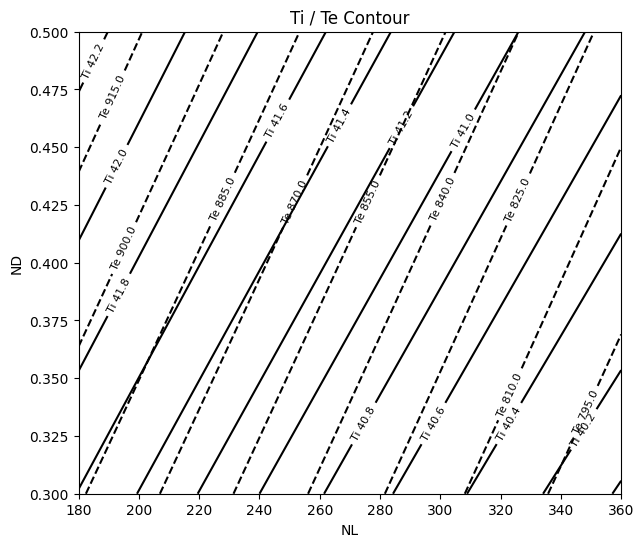

In [16]:
import matplotlib.pyplot as plt

# -------------------------
# 建立 grid
# -------------------------

x0 = np.linspace(min_v[0], max_v[0], 80)
x1 = np.linspace(min_v[1], max_v[1], 80)

X0, X1 = np.meshgrid(x0, x1)

# 固定其他變數
x2 = (max_v[2] + min_v[2]) / 2
x3 = (max_v[3] + min_v[3]) / 2

grid = np.column_stack([
    X0.ravel(),
    X1.ravel(),
    np.full(X0.size, x2),
    np.full(X0.size, x3)
])

# 正規化
grid_norm = (grid - min_v[0:4]) / (max_v[0:4] - min_v[0:4])

Xg = np.hstack((grid_norm, np.ones((grid_norm.shape[0],1))))

# -------------------------
# NN prediction
# -------------------------

h = logistic(Xg @ W1)
H = np.hstack((h, np.ones((h.shape[0],1))))
out = logistic(H @ W2)

# 反正規化
out_real = out * (max_v[4:6] - min_v[4:6]) + min_v[4:6]

Ti = out_real[:,0].reshape(X0.shape)
Te = out_real[:,1].reshape(X0.shape)

# -------------------------
# 畫等高線
# -------------------------

plt.figure(figsize=(7,6))

# Ti 實線
cs1 = plt.contour(X0, X1, Ti, levels=12, colors='black')
plt.clabel(cs1, fmt="Ti %.1f", fontsize=8)

# Te 虛線
cs2 = plt.contour(X0, X1, Te, levels=12, colors='black', linestyles='dashed')
plt.clabel(cs2, fmt="Te %.1f", fontsize=8)

plt.xlabel("NL")
plt.ylabel("ND")
plt.title("Ti / Te Contour")

plt.show()

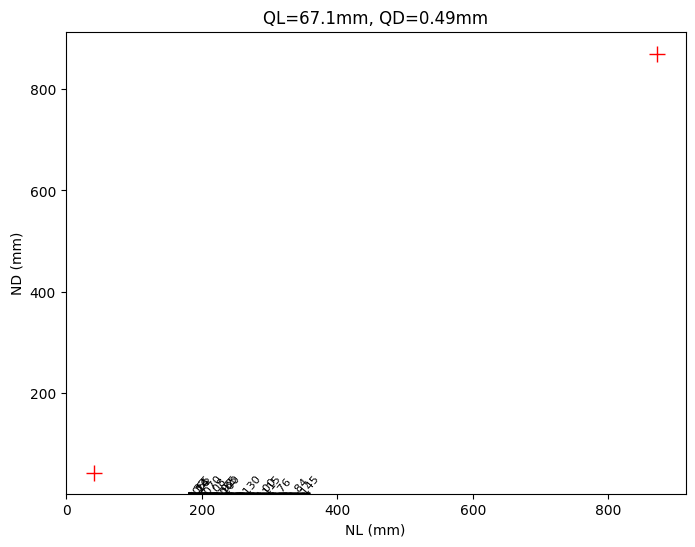

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def evaluate(pop):

    x = (pop - min_v[0:4]) / (max_v[0:4]-min_v[0:4])
    X = np.hstack((x, np.ones((x.shape[0], 1))))
    h = logistic(X @ W1)
    H = np.hstack((h, np.ones((h.shape[0],1))))
    return logistic(H @ W2)

# grid
x0 = np.linspace(min_v[0], max_v[0], 120)
x1 = np.linspace(min_v[1], max_v[1], 120)

X0, X1 = np.meshgrid(x0, x1)

# 固定其他變數 (用GA最佳解)
x2 = 253.6
x3 = 0.43

grid = np.zeros((X0.size,4))

grid[:,0] = X0.ravel()
grid[:,1] = X1.ravel()
grid[:,2] = 253.6
grid[:,3] = 0.43

# NN prediction
out = evaluate(grid)

# 反正規化
OV_out = out*(max_v[4:6]-min_v[4:6]) + min_v[4:6]

Ti = OV_out[:,0].reshape(X0.shape)
Te = OV_out[:,1].reshape(X0.shape)

# ---------------- plot ----------------

plt.figure(figsize=(8,6))

# Ti contour (實線)
cs1 = plt.contour(
    X0, X1, Ti,
    levels=10,
    colors='black',
    linestyles='solid'
)

# Te contour (虛線)
cs2 = plt.contour(
    X0, X1, Te,
    levels=10,
    colors='black',
    linestyles='dashed'
)

plt.clabel(cs1, inline=True, fontsize=8)
plt.clabel(cs2, inline=True, fontsize=8)

# GA最佳解
plt.plot(OV[0], OV[1], 'r+', markersize=12)

plt.xlabel("NL (mm)")
plt.ylabel("ND (mm)")

plt.title("QL=67.1mm, QD=0.49mm")

plt.show()

In [ ]:
# normalize
grid_norm = (grid - min_v[0:4])/(max_v[0:4]-min_v[0:4])

# NN prediction
out = evaluate(grid_norm)

# denormalize output
OV_out = out*(max_v[4:6]-min_v[4:6]) + min_v[4:6]

Ti = OV_out[:,0].reshape(X0.shape)
Te = OV_out[:,1].reshape(X0.shape)

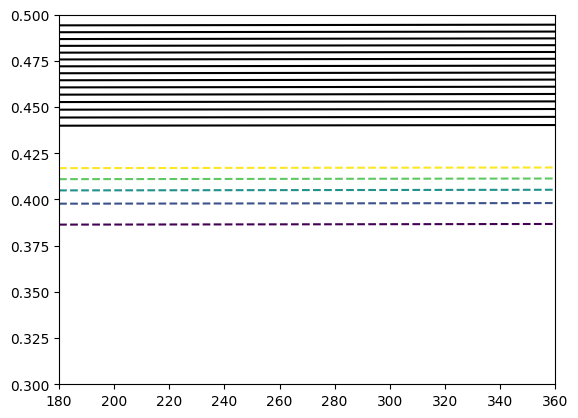

In [ ]:
cs1 = plt.contour(X0,X1,Ti,levels=np.arange(33,36,0.2),colors='black')
cs2 = plt.contour(X0,X1,Te,levels=np.arange(725,850,25),linestyles='dashed')

(0.3, 0.5)

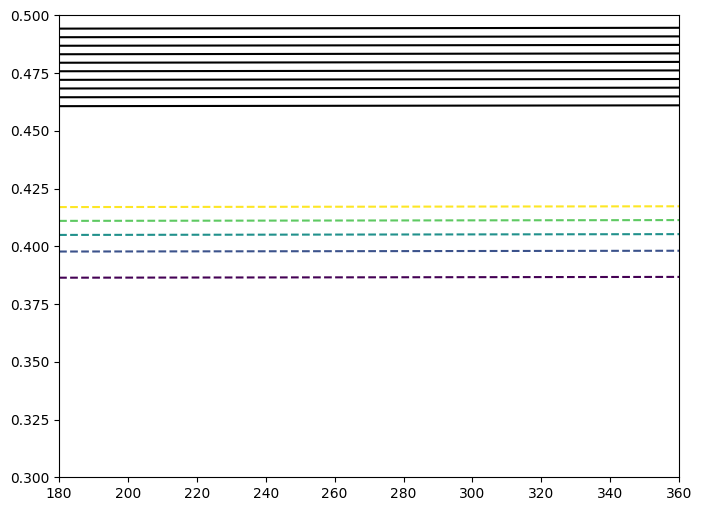

In [ ]:
plt.figure(figsize=(8,6))
plt.contour(X0,X1,Ti,levels=np.arange(34,36,0.2),colors='black')
plt.contour(X0,X1,Te,levels=np.arange(725,850,25),linestyles='dashed')

plt.plot(OV[0],OV[1],'r+',markersize=12)

plt.xlim(min_v[0],max_v[0])
plt.ylim(min_v[1],max_v[1])

In [ ]:
import matplotlib.pyplot as plt

# ---------- grid ----------
x0 = np.linspace(min_v[0], max_v[0], 120)
x1 = np.linspace(min_v[1], max_v[1], 120)

X0, X1 = np.meshgrid(x0, x1)

# 固定另外兩個變數
x2 = OV[2]
x3 = OV[3]

grid = np.zeros((X0.size,4))
grid[:,0] = X0.ravel()
grid[:,1] = X1.ravel()
grid[:,2] = x2
grid[:,3] = x3

ValueError: could not broadcast input array from shape (2,) into shape (14400,)

In [ ]:
X0.ravel()

array([180.        , 181.51260504, 183.02521008, ..., 356.97478992,
       358.48739496, 360.        ])

In [ ]:
import matplotlib.pyplot as plt

# ---------- grid ----------
x0 = np.linspace(min_v[0], max_v[0], 120)
x1 = np.linspace(min_v[1], max_v[1], 120)

X0, X1 = np.meshgrid(x0, x1)

# 固定另外兩個變數
x2 = OV[2]
x3 = OV[3]

grid = np.zeros((X0.size,4))
grid[:,0] = X0.ravel()
grid[:,1] = X1.ravel()
grid[:,2] = x2
grid[:,3] = x3

# ---------- NN prediction ----------
out = evaluate(grid)

# 反正規化
OV_out = out*(max_v[4:6]-min_v[4:6]) + min_v[4:6]

Ti = OV_out[:,0].reshape(X0.shape)
Te = OV_out[:,1].reshape(X0.shape)

# ---------- contour ----------
plt.figure(figsize=(7,5))

# Ti contour (實線)
c1 = plt.contour(X0, X1, Ti, colors='black', linewidths=1)
plt.clabel(c1, inline=True, fontsize=8)

# Te contour (虛線)
c2 = plt.contour(X0, X1, Te, colors='black', linestyles='dashed')
plt.clabel(c2, inline=True, fontsize=8)

# GA最佳解
plt.scatter(OV[0], OV[1], color='red', s=80)
plt.text(OV[0]+2, OV[1], f"Ti={OV[4]:.1f}, Te={OV[5]:.0f}")

plt.xlabel("NL (mm)")
plt.ylabel("ND (mm)")

plt.title(f"QL={OV[2]:.1f}mm, QD={OV[3]:.2f}mm")

plt.grid(True)

plt.show()

ValueError: could not broadcast input array from shape (2,) into shape (14400,)

In [ ]:
X1.ravel()

array([0.3, 0.3, 0.3, ..., 0.5, 0.5, 0.5])